In [1]:
import pandas as pd
import numpy as np
import json

# load news with finbert + bart scores
news = pd.read_csv("data/news_scored_raw.csv", encoding="utf-8-sig")
news["Date"] = pd.to_datetime(news["Date"]).dt.normalize()
news["bart_scores"] = news["bart_scores_json"].apply(json.loads)

# load fomc phase labels
fomc = pd.read_csv("data/fomc_statements.csv")
fomc["Date"] = pd.to_datetime(fomc["Date"]).dt.normalize()
fomc = fomc.sort_values("Date").reset_index(drop=True)

print(f"News: {len(news)} articles, {news['Ticker'].nunique()} tickers")
print(news["Ticker"].value_counts())
print(f"\nDate range: {news['Date'].min().date()} to {news['Date'].max().date()}")
print(f"\nFOMC phases:\n{fomc['Monetary_Phase'].value_counts()}")

News: 12996 articles, 5 tickers
Ticker
AMZN     3952
MSFT     2640
NVDA     2403
META     2388
GOOGL    1613
Name: count, dtype: int64

Date range: 2021-01-04 to 2025-12-30

FOMC phases:
Monetary_Phase
Phase 3: 高位维持/降息    16
Phase 2: 加息周期       11
Phase 1: QE/零利率      9
Name: count, dtype: int64


In [2]:
def assign_phase(date):
    past = fomc[fomc["Date"] <= date]
    if len(past) == 0:
        return "Phase 1: QE/零利率"
    return past.iloc[-1]["Monetary_Phase"]

news["phase"] = news["Date"].apply(assign_phase)

print(news["phase"].value_counts())
print()
print(news.groupby("phase")["Return_tomorrow"].describe().round(4))

phase
Phase 3: 高位维持/降息    7975
Phase 2: 加息周期       2858
Phase 1: QE/零利率     2163
Name: count, dtype: int64

                   count    mean     std     min     25%     50%     75%  \
phase                                                                      
Phase 1: QE/零利率   2163.0 -0.0003  0.0276 -0.2639 -0.0091 -0.0001  0.0105   
Phase 2: 加息周期     2858.0  0.0015  0.0381 -0.2456 -0.0147  0.0014  0.0181   
Phase 3: 高位维持/降息  7970.0  0.0013  0.0294 -0.1697 -0.0119  0.0012  0.0134   

                     max  
phase                     
Phase 1: QE/零利率   0.1354  
Phase 2: 加息周期     0.2437  
Phase 3: 高位维持/降息  0.2032  


In [3]:
BART_THRESH = 0.6
FINBERT_THRESH = 0.6
CATEGORIES = ["chip", "power", "algorithm", "regulation", "earnings"]
TICKERS = ["NVDA", "MSFT", "META", "AMZN", "GOOGL"]

# for each ticker-category pair, compute daily sentiment score
records = []

for ticker in TICKERS:
    for cat in CATEGORIES:
        subset = news[
            (news["Ticker"] == ticker) &
            (news["finbert_conf"] >= FINBERT_THRESH) &
            (news["bart_scores"].apply(lambda x: x.get(cat, 0) >= BART_THRESH))
        ]
        daily = subset.groupby("Date")["finbert_score"].sum().reset_index()
        daily.columns = ["Date", "sentiment"]
        daily["ticker_cat"] = f"{ticker}_{cat}"
        records.append(daily)

sentiment_long = pd.concat(records, ignore_index=True)

print(f"Total ticker-category-day records: {len(sentiment_long)}")
print(f"\nTop 10 most active ticker-category pairs:")
print(sentiment_long.groupby("ticker_cat").size().sort_values(ascending=False).head(10))

Total ticker-category-day records: 2037

Top 10 most active ticker-category pairs:
ticker_cat
NVDA_chip         225
NVDA_algorithm    193
AMZN_power        130
NVDA_power        123
NVDA_earnings     115
MSFT_power        107
MSFT_algorithm    105
MSFT_earnings      85
AMZN_earnings      83
AMZN_algorithm     76
dtype: int64


In [4]:
# build portfolio return series (equal-weighted average of 5 stocks)
stock_files = ["NVDA", "MSFT", "META", "AMZN", "GOOGL"]
stock_dfs = []
for t in stock_files:
    df = pd.read_csv(f"data/{t}.csv")
    df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None).dt.normalize()
    df["Ticker"] = t
    stock_dfs.append(df[["Date", "Ticker", "Daily_Return"]])

stocks = pd.concat(stock_dfs, ignore_index=True)
portfolio = stocks.groupby("Date")["Daily_Return"].mean().reset_index()
portfolio.columns = ["Date", "port_return"]
portfolio = portfolio.sort_values("Date").reset_index(drop=True)
portfolio["next_return"] = portfolio["port_return"].shift(-1)
portfolio["rolling_std"] = portfolio["port_return"].rolling(5).std()
portfolio = portfolio.dropna().reset_index(drop=True)

# assign phase to each trading day
portfolio["phase"] = portfolio["Date"].apply(assign_phase)

# pivot sentiment_long to wide format and merge
sentiment_wide = sentiment_long.pivot_table(
    index="Date", columns="ticker_cat", values="sentiment", fill_value=0
).reset_index()

data = pd.merge(portfolio, sentiment_wide, on="Date", how="left")
sent_cols = [c for c in sentiment_wide.columns if c != "Date"]
data[sent_cols] = data[sent_cols].fillna(0)

print(f"Portfolio days: {len(data)}")
print(f"Sentiment signal days: {(data[sent_cols] != 0).any(axis=1).sum()}")
print(f"Feature columns: {len(sent_cols)}")
print(data[["Date", "phase", "port_return", "next_return", "rolling_std"]].head())

Portfolio days: 1248
Sentiment signal days: 659
Feature columns: 25
        Date            phase  port_return  next_return  rolling_std
0 2021-01-11  Phase 1: QE/零利率    -0.013692    -0.010562     0.022371
1 2021-01-12  Phase 1: QE/零利率    -0.010562     0.006465     0.021935
2 2021-01-13  Phase 1: QE/零利率     0.006465    -0.017034     0.016911
3 2021-01-14  Phase 1: QE/零利率    -0.017034    -0.002719     0.010522
4 2021-01-15  Phase 1: QE/零利率    -0.002719     0.021537     0.009441


In [5]:
PHASES = ["Phase 1: QE/零利率", "Phase 2: 加息周期", "Phase 3: 高位维持/降息"]
CATEGORIES = ["chip", "power", "algorithm", "regulation", "earnings"]
TICKERS = ["NVDA", "MSFT", "META", "AMZN", "GOOGL"]

# build per-stock daily sentiment by category
sent_records = []
for ticker in TICKERS:
    for cat in CATEGORIES:
        subset = news[
            (news["Ticker"] == ticker) &
            (news["finbert_conf"] >= FINBERT_THRESH) &
            (news["bart_scores"].apply(lambda x: x.get(cat, 0) >= BART_THRESH))
        ]
        daily = subset.groupby("Date")["finbert_score"].sum().reset_index()
        daily.columns = ["Date", f"{ticker}_{cat}"]
        sent_records.append(daily)

# merge all into one wide table per trading day
from functools import reduce
sent_wide = reduce(lambda a, b: pd.merge(a, b, on="Date", how="outer"), sent_records)
sent_wide = sent_wide.fillna(0)

# merge with portfolio data
data = pd.merge(portfolio, sent_wide, on="Date", how="left")
feat_cols = [c for c in sent_wide.columns if c != "Date"]
data[feat_cols] = data[feat_cols].fillna(0)

# phase dummies (Phase 1 as baseline)
data["phase2"] = (data["phase"] == "Phase 2: 加息周期").astype(int)
data["phase3"] = (data["phase"] == "Phase 3: 高位维持/降息").astype(int)

# shock: previous day return if |return| > rolling_std, else 0
data["shock"] = np.where(
    data["port_return"].abs() > data["rolling_std"],
    data["port_return"],
    0
)

print(f"Total trading days: {len(data)}")
print(f"Shock days: {(data['shock'] != 0).sum()}")
print(f"Feature columns: {len(feat_cols)}")

Total trading days: 1248
Shock days: 451
Feature columns: 25


In [8]:
import statsmodels.api as sm

CATEGORIES = ["chip", "power", "algorithm", "regulation", "earnings"]
TICKERS = ["NVDA", "MSFT", "META", "AMZN", "GOOGL"]

# load individual stock returns and compute per-stock shock
stock_data = {}
for ticker in TICKERS:
    df = pd.read_csv(f"data/{ticker}.csv")
    df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None).dt.normalize()
    df = df.sort_values("Date").reset_index(drop=True)
    df["rolling_std"] = df["Daily_Return"].rolling(5).std()
    df["shock"] = np.where(df["Daily_Return"].abs() > df["rolling_std"], df["Daily_Return"], 0)
    stock_data[ticker] = df[["Date", "Daily_Return", "rolling_std", "shock"]]

# run regression per ticker
results = {}

for ticker in TICKERS:
    # get this stock's sentiment signals
    ticker_cols = [f"{ticker}_{cat}" for cat in CATEGORIES]
    sent_df = data[["Date", "phase2", "phase3"] + ticker_cols].copy()

    # merge with this stock's own returns and shock
    stock_df = stock_data[ticker].copy()
    stock_df["Return_tomorrow"] = stock_df["Daily_Return"].shift(-1)
    
    df = pd.merge(sent_df, stock_df[["Date", "shock", "Return_tomorrow"]], on="Date", how="inner")
    
    # pos/neg split
    for col in ticker_cols:
        df[f"{col}_pos"] = df[col].clip(lower=0)
        df[f"{col}_neg"] = df[col].clip(upper=0)
    
    pos_cols = [f"{c}_pos" for c in ticker_cols]
    neg_cols = [f"{c}_neg" for c in ticker_cols]
    feature_cols = pos_cols + neg_cols + ["phase2", "phase3", "shock"]
    
    # keep signal days only
    has_signal = (df[pos_cols + neg_cols] != 0).any(axis=1)
    df = df[has_signal].dropna(subset=["Return_tomorrow"] + feature_cols).copy()
    
    X = sm.add_constant(df[feature_cols])
    y = df["Return_tomorrow"]
    model = sm.OLS(y, X).fit(cov_type="HC3")
    results[ticker] = (model, df)

    print(f"\n{'='*60}")
    print(f"{ticker} | n={len(df)} | R²={model.rsquared:.4f} | Adj R²={model.rsquared_adj:.4f}")
    print(f"{'Variable':<25} {'coef':>10} {'t':>8} {'p':>8} {'sig':>5}")
    print("-" * 60)
    for var in model.params.index:
        coef = model.params[var]
        t = model.tvalues[var]
        p = model.pvalues[var]
        sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
        print(f"{var:<25} {coef:>10.5f} {t:>8.3f} {p:>8.3f} {sig:>5}")


NVDA | n=281 | R²=0.0683 | Adj R²=0.0230
Variable                        coef        t        p   sig
------------------------------------------------------------
const                        0.00826    0.973    0.330      
NVDA_chip_pos                0.00588    1.420    0.156      
NVDA_power_pos              -0.00240   -0.459    0.646      
NVDA_algorithm_pos           0.00673    1.369    0.171      
NVDA_regulation_pos         -0.01623   -1.012    0.312      
NVDA_earnings_pos           -0.00621   -1.723    0.085     *
NVDA_chip_neg                0.00076    0.258    0.797      
NVDA_power_neg              -0.00715   -0.886    0.375      
NVDA_algorithm_neg          -0.00037   -0.063    0.950      
NVDA_regulation_neg          0.00250    0.661    0.508      
NVDA_earnings_neg            0.00446    1.440    0.150      
phase2                       0.00814    0.543    0.587      
phase3                      -0.00792   -0.897    0.370      
shock                       -0.16962   -2.2

In [9]:
# significant variables identified from full regression
slim_features = {
    "NVDA": ["NVDA_earnings_pos", "NVDA_chip_pos", "NVDA_algorithm_pos", "shock"],
    "MSFT": ["MSFT_earnings_pos", "MSFT_power_neg", "MSFT_algorithm_pos", "shock"],
    "META": ["META_regulation_pos", "META_earnings_neg", "phase2", "shock"],
    "AMZN": ["AMZN_earnings_pos", "AMZN_earnings_neg", "shock"],
    "GOOGL": ["GOOGL_earnings_neg", "GOOGL_power_pos", "GOOGL_chip_pos", "shock"],
}

slim_results = {}

for ticker in TICKERS:
    model_full, df_full = results[ticker]
    
    feature_cols = slim_features[ticker]
    df = df_full.dropna(subset=["Return_tomorrow"] + feature_cols).copy()
    
    X = sm.add_constant(df[feature_cols])
    y = df["Return_tomorrow"]
    model = sm.OLS(y, X).fit(cov_type="HC3")
    slim_results[ticker] = (model, df)

    print(f"\n{'='*55}")
    print(f"{ticker} | n={len(df)} | R²={model.rsquared:.4f} | Adj R²={model.rsquared_adj:.4f}")
    print(f"{'Variable':<25} {'coef':>10} {'t':>8} {'p':>8} {'sig':>5}")
    print("-" * 55)
    for var in model.params.index:
        coef = model.params[var]
        t = model.tvalues[var]
        p = model.pvalues[var]
        sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
        print(f"{var:<25} {coef:>10.5f} {t:>8.3f} {p:>8.3f} {sig:>5}")


NVDA | n=281 | R²=0.0287 | Adj R²=0.0147
Variable                        coef        t        p   sig
-------------------------------------------------------
const                        0.00178    0.655    0.512      
NVDA_earnings_pos           -0.00472   -1.229    0.219      
NVDA_chip_pos                0.00328    0.780    0.436      
NVDA_algorithm_pos           0.00559    1.211    0.226      
shock                       -0.12909   -1.860    0.063     *

MSFT | n=206 | R²=0.0826 | Adj R²=0.0643
Variable                        coef        t        p   sig
-------------------------------------------------------
const                        0.00144    0.965    0.334      
MSFT_earnings_pos            0.00946    2.490    0.013    **
MSFT_power_neg               0.00470    2.412    0.016    **
MSFT_algorithm_pos          -0.00501   -1.368    0.171      
shock                       -0.01765   -0.202    0.840      

META | n=173 | R²=0.1292 | Adj R²=0.1084
Variable                      

In [ ]:
# keep variables with p < 0.5 from full regression
sig_vars = [var for var in model_full.params.index 
            if var != "const" and model_full.pvalues[var] < 0.5]

print(f"Selected {len(sig_vars)} variables:")
print(sig_vars)

df_signal2 = df_signal.copy()
for col in sig_vars:
    if col not in df_signal2.columns:
        base = col.replace("_pos", "").replace("_neg", "")
        df_signal2[col] = df[base].clip(lower=0) if "_pos" in col else df[base].clip(upper=0)

X2 = sm.add_constant(df_signal2[sig_vars])
y2 = df_signal2["next_return"]
model_slim = sm.OLS(y2, X2).fit(cov_type="HC3")

print(f"\nn={len(df_signal2)} | R²={model_slim.rsquared:.4f} | Adj R²={model_slim.rsquared_adj:.4f}")
print(f"\n{'Variable':<25} {'coef':>10} {'t':>8} {'p':>8} {'sig':>5}")
print("-" * 60)
for var in model_slim.params.index:
    coef = model_slim.params[var]
    t = model_slim.tvalues[var]
    p = model_slim.pvalues[var]
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    print(f"{var:<25} {coef:>10.5f} {t:>8.3f} {p:>8.3f} {sig:>5}")

Selected 27 variables:
['NVDA_chip_pos', 'NVDA_power_pos', 'NVDA_algorithm_pos', 'NVDA_earnings_pos', 'MSFT_power_pos', 'MSFT_algorithm_pos', 'MSFT_earnings_pos', 'META_chip_pos', 'META_algorithm_pos', 'META_earnings_pos', 'AMZN_power_pos', 'AMZN_earnings_pos', 'GOOGL_chip_pos', 'GOOGL_power_pos', 'GOOGL_algorithm_pos', 'NVDA_power_neg', 'NVDA_regulation_neg', 'NVDA_earnings_neg', 'MSFT_power_neg', 'MSFT_algorithm_neg', 'META_algorithm_neg', 'META_regulation_neg', 'AMZN_regulation_neg', 'GOOGL_earnings_neg', 'phase2', 'phase3', 'shock']

n=659 | R²=0.0793 | Adj R²=0.0399

Variable                        coef        t        p   sig
------------------------------------------------------------
const                       -0.00255   -1.178    0.239      
NVDA_chip_pos                0.00182    1.165    0.244      
NVDA_power_pos              -0.00303   -1.207    0.227      
NVDA_algorithm_pos           0.00397    2.127    0.033    **
NVDA_earnings_pos           -0.00430   -2.693    0.007 

In [18]:
sig_vars2 = [var for var in model_slim.params.index 
             if var != "const" and model_slim.pvalues[var] < 0.2]

print(f"Selected {len(sig_vars2)} variables:")
print(sig_vars2)

X3 = sm.add_constant(df_signal2[sig_vars2])
y3 = df_signal2["next_return"]
model_final = sm.OLS(y3, X3).fit(cov_type="HC3")

print(f"\nn={len(df_signal2)} | R²={model_final.rsquared:.4f} | Adj R²={model_final.rsquared_adj:.4f}")
print(f"\n{'Variable':<25} {'coef':>10} {'t':>8} {'p':>8} {'sig':>5}")
print("-" * 60)
for var in model_final.params.index:
    coef = model_final.params[var]
    t = model_final.tvalues[var]
    p = model_final.pvalues[var]
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    print(f"{var:<25} {coef:>10.5f} {t:>8.3f} {p:>8.3f} {sig:>5}")

Selected 16 variables:
['NVDA_algorithm_pos', 'NVDA_earnings_pos', 'MSFT_power_pos', 'MSFT_algorithm_pos', 'META_algorithm_pos', 'META_earnings_pos', 'AMZN_earnings_pos', 'GOOGL_power_pos', 'NVDA_power_neg', 'NVDA_regulation_neg', 'NVDA_earnings_neg', 'MSFT_power_neg', 'MSFT_algorithm_neg', 'GOOGL_earnings_neg', 'phase2', 'phase3']

n=659 | R²=0.0682 | Adj R²=0.0450

Variable                        coef        t        p   sig
------------------------------------------------------------
const                       -0.00226   -1.082    0.279      
NVDA_algorithm_pos           0.00353    2.266    0.023    **
NVDA_earnings_pos           -0.00311   -2.310    0.021    **
MSFT_power_pos               0.00422    1.013    0.311      
MSFT_algorithm_pos          -0.00247   -0.645    0.519      
META_algorithm_pos          -0.00773   -2.005    0.045    **
META_earnings_pos            0.00685    3.045    0.002   ***
AMZN_earnings_pos            0.00082    0.700    0.484      
GOOGL_power_pos     

In [19]:
sig_vars3 = [var for var in model_final.params.index 
             if var != "const" and model_final.pvalues[var] < 0.25]

print(f"Selected {len(sig_vars3)} variables:")
print(sig_vars3)

X4 = sm.add_constant(df_signal2[sig_vars3])
y4 = df_signal2["next_return"]
model_v3 = sm.OLS(y4, X4).fit(cov_type="HC3")

print(f"\nn={len(df_signal2)} | R²={model_v3.rsquared:.4f} | Adj R²={model_v3.rsquared_adj:.4f}")
print(f"\n{'Variable':<25} {'coef':>10} {'t':>8} {'p':>8} {'sig':>5}")
print("-" * 60)
for var in model_v3.params.index:
    coef = model_v3.params[var]
    t = model_v3.tvalues[var]
    p = model_v3.pvalues[var]
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    print(f"{var:<25} {coef:>10.5f} {t:>8.3f} {p:>8.3f} {sig:>5}")

Selected 13 variables:
['NVDA_algorithm_pos', 'NVDA_earnings_pos', 'META_algorithm_pos', 'META_earnings_pos', 'GOOGL_power_pos', 'NVDA_power_neg', 'NVDA_regulation_neg', 'NVDA_earnings_neg', 'MSFT_power_neg', 'MSFT_algorithm_neg', 'GOOGL_earnings_neg', 'phase2', 'phase3']

n=659 | R²=0.0625 | Adj R²=0.0436

Variable                        coef        t        p   sig
------------------------------------------------------------
const                       -0.00222   -1.064    0.287      
NVDA_algorithm_pos           0.00340    2.197    0.028    **
NVDA_earnings_pos           -0.00294   -2.255    0.024    **
META_algorithm_pos          -0.00779   -2.133    0.033    **
META_earnings_pos            0.00777    4.105    0.000   ***
GOOGL_power_pos              0.00490    1.879    0.060     *
NVDA_power_neg              -0.00460   -1.794    0.073     *
NVDA_regulation_neg          0.00104    1.272    0.203      
NVDA_earnings_neg            0.00196    1.512    0.130      
MSFT_power_neg      

In [20]:
selected = []
remaining = candidate_vars.copy()
current_aic = sm.OLS(df_signal2["next_return"],
                     sm.add_constant(pd.DataFrame(index=df_signal2.index))).fit().aic

print(f"Baseline AIC (intercept only): {current_aic:.2f}")
print()

while remaining:
    aic_scores = {}
    for var in remaining:
        cols = selected + [var]
        X_try = sm.add_constant(df_signal2[cols])
        m = sm.OLS(df_signal2["next_return"], X_try).fit()
        aic_scores[var] = m.aic
    
    best_var = min(aic_scores, key=aic_scores.get)
    best_aic = aic_scores[best_var]
    
    if best_aic < current_aic:
        selected.append(best_var)
        remaining.remove(best_var)
        current_aic = best_aic
        print(f"Added: {best_var:<25} AIC={best_aic:.2f}")
    else:
        break

print(f"\nFinal selected variables ({len(selected)}):")
print(selected)

X_final = sm.add_constant(df_signal2[selected])
model_aic = sm.OLS(df_signal2["next_return"], X_final).fit(cov_type="HC3")

print(f"\nn={len(df_signal2)} | R²={model_aic.rsquared:.4f} | Adj R²={model_aic.rsquared_adj:.4f} | AIC={model_aic.aic:.2f}")
print(f"\n{'Variable':<25} {'coef':>10} {'t':>8} {'p':>8} {'sig':>5}")
print("-" * 60)
for var in model_aic.params.index:
    coef = model_aic.params[var]
    t = model_aic.tvalues[var]
    p = model_aic.pvalues[var]
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    print(f"{var:<25} {coef:>10.5f} {t:>8.3f} {p:>8.3f} {sig:>5}")

Baseline AIC (intercept only): -3255.58

Added: GOOGL_earnings_neg        AIC=-3262.12
Added: phase2                    AIC=-3265.88
Added: MSFT_power_neg            AIC=-3268.05
Added: META_earnings_pos         AIC=-3269.55
Added: META_algorithm_pos        AIC=-3274.50
Added: MSFT_power_pos            AIC=-3276.11
Added: phase3                    AIC=-3276.71

Final selected variables (7):
['GOOGL_earnings_neg', 'phase2', 'MSFT_power_neg', 'META_earnings_pos', 'META_algorithm_pos', 'MSFT_power_pos', 'phase3']

n=659 | R²=0.0519 | Adj R²=0.0417 | AIC=-3276.71

Variable                        coef        t        p   sig
------------------------------------------------------------
const                       -0.00209   -1.003    0.316      
GOOGL_earnings_neg           0.00479    1.632    0.103      
phase2                       0.00779    2.538    0.011    **
MSFT_power_neg               0.00334    1.830    0.067     *
META_earnings_pos            0.00620    3.938    0.000   ***
META_a

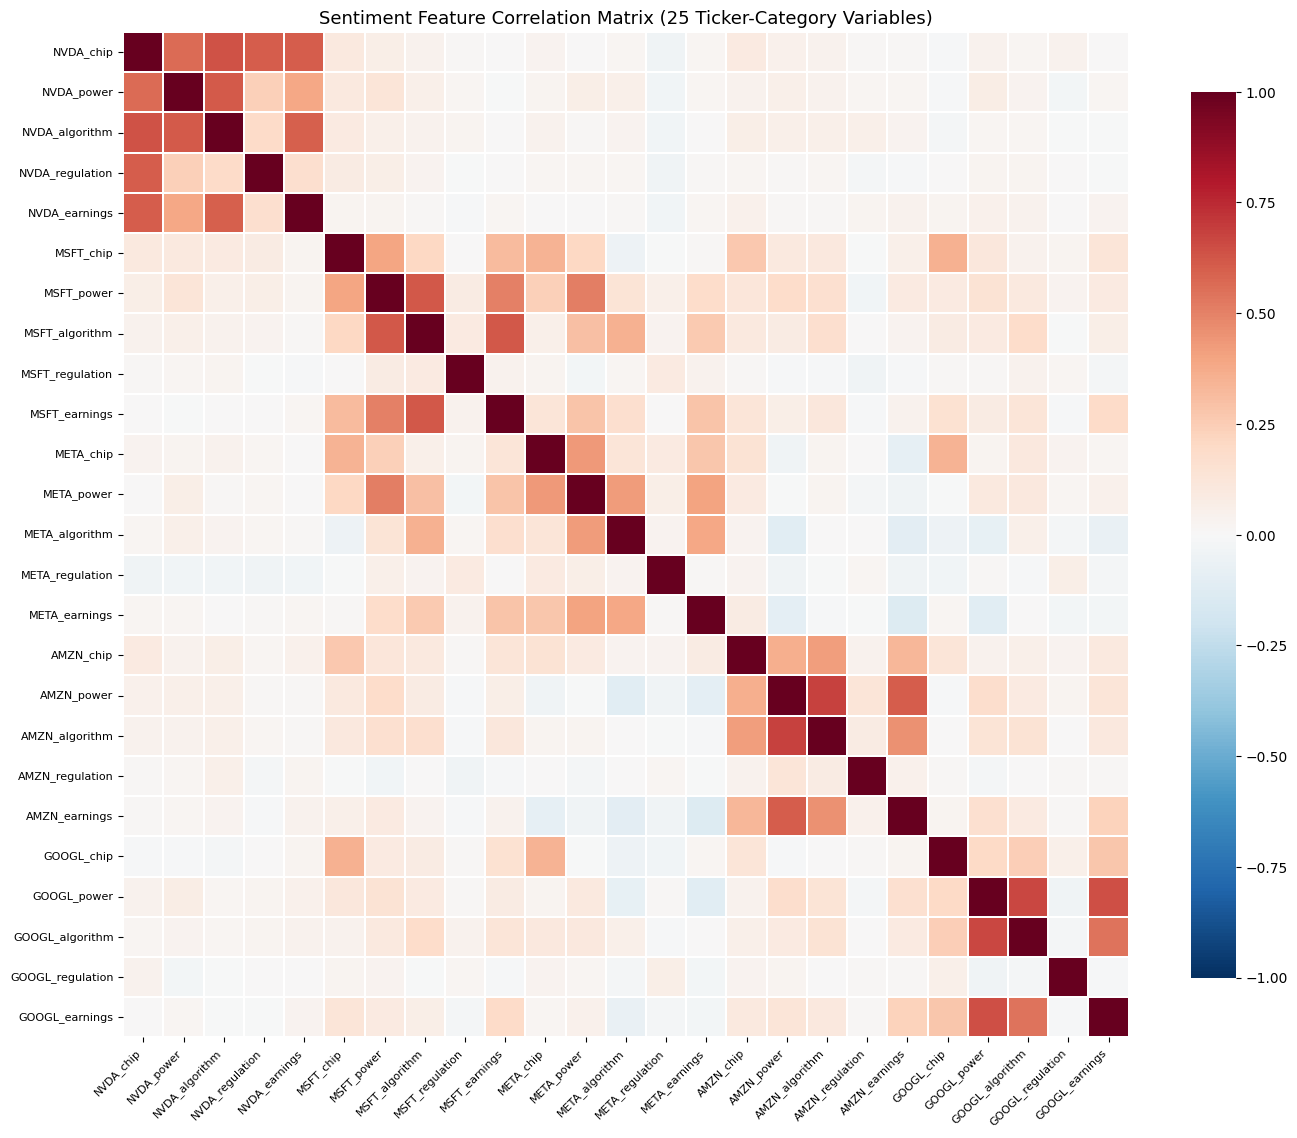

Saved.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_cols = [f"{t}_{c}" for t in TICKERS for c in CATEGORIES]
corr = df_signal3[feat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    square=True,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Sentiment Feature Correlation Matrix (25 Ticker-Category Variables)", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("output/correlation_matrix.png", dpi=150)
plt.show()
print("Saved.")

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# for each ticker, run PCA on its 5 category sentiment scores
# extract first principal component as the ticker's composite sentiment
for ticker in TICKERS:
    ticker_cols = [f"{ticker}_{cat}" for cat in CATEGORIES]
    X = df_signal3[ticker_cols].values
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=1)
    df_signal3[f"{ticker}_pc1"] = pca.fit_transform(X_scaled)
    var_explained = pca.explained_variance_ratio_[0]
    print(f"{ticker}: PC1 explains {var_explained:.1%} of within-ticker variance")

print()

# AIC forward stepwise with PC1 scores + controls
pc1_cols = [f"{t}_pc1" for t in TICKERS]
candidate_vars_pca = pc1_cols + ["phase2", "phase3", "shock"]

selected_pca = []
remaining_pca = candidate_vars_pca.copy()
current_aic = sm.OLS(
    df_signal3["drift"],
    sm.add_constant(pd.DataFrame(index=df_signal3.index))
).fit().aic

print(f"Baseline AIC: {current_aic:.2f}")
print()

while remaining_pca:
    aic_scores = {}
    for var in remaining_pca:
        cols = selected_pca + [var]
        X_try = sm.add_constant(df_signal3[cols])
        m = sm.OLS(df_signal3["drift"], X_try).fit()
        aic_scores[var] = m.aic

    best_var = min(aic_scores, key=aic_scores.get)
    best_aic = aic_scores[best_var]

    if best_aic < current_aic:
        selected_pca.append(best_var)
        remaining_pca.remove(best_var)
        current_aic = best_aic
        print(f"Added: {best_var:<20} AIC={best_aic:.2f}")
    else:
        break

print(f"\nFinal variables ({len(selected_pca)}): {selected_pca}")

X_pca = sm.add_constant(df_signal3[selected_pca])
y_pca = df_signal3["drift"]
model_pca = sm.OLS(y_pca, X_pca).fit(cov_type="HC3")

print(f"\nn={len(df_signal3)} | R²={model_pca.rsquared:.4f} | Adj R²={model_pca.rsquared_adj:.4f} | AIC={model_pca.aic:.2f}")
print(f"\n{'Variable':<20} {'coef':>10} {'t':>8} {'p':>8} {'sig':>5}")
print("-" * 55)
for var in model_pca.params.index:
    coef = model_pca.params[var]
    t = model_pca.tvalues[var]
    p = model_pca.pvalues[var]
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    print(f"{var:<20} {coef:>10.5f} {t:>8.3f} {p:>8.3f} {sig:>5}")

NVDA: PC1 explains 58.2% of within-ticker variance
MSFT: PC1 explains 47.5% of within-ticker variance
META: PC1 explains 41.1% of within-ticker variance
AMZN: PC1 explains 49.3% of within-ticker variance
GOOGL: PC1 explains 47.4% of within-ticker variance

Baseline AIC: -3219.12

Added: GOOGL_pc1            AIC=-3221.05
Added: phase2               AIC=-3222.88
Added: shock                AIC=-3223.62

Final variables (3): ['GOOGL_pc1', 'phase2', 'shock']

n=659 | R²=0.0158 | Adj R²=0.0113 | AIC=-3223.62

Variable                   coef        t        p   sig
-------------------------------------------------------
const                  -0.00096   -1.150    0.250      
GOOGL_pc1               0.00110    1.461    0.144      
phase2                  0.00422    1.704    0.088     *
shock                  -0.07626   -1.314    0.189      


# Regression Methodology: Sentiment-Return Analysis

## 1. Sentiment Signal Construction

Prior to regression, raw news articles are processed through a two-stage filtering and aggregation pipeline.

- **FinBERT confidence filter**: Only articles with `finbert_conf ≥ 0.6` are retained, ensuring reliable polarity classification.
- **BART category filter**: For each article, BART zero-shot classification produces confidence scores across five narrative categories (chip / power / algorithm / regulation / earnings). An article is assigned to a category only if its score meets or exceeds 0.6. Multi-label assignment is permitted.
- **Daily aggregation**: For each ticker-category-day triplet, the signed FinBERT scores of all qualifying articles are summed to produce the daily sentiment signal $S_{i,k,t}$:

$$
S_{i,k,t} = \sum_{a \in \mathcal{A}_{i,k,t}} \text{finbert\_score}_a
$$

where:
- $i$ = stock ticker (NVDA / MSFT / META / AMZN / GOOGL)
- $k$ = narrative category (chip / power / algorithm / regulation / earnings)
- $t$ = trading day
- $\mathcal{A}_{i,k,t}$ = set of articles on day $t$ about stock $i$ in category $k$ that pass both confidence filters

A positive value indicates net positive sentiment for that ticker-category on that day; a negative value indicates net negative sentiment.

To capture asymmetric effects, the signal is further decomposed into positive and negative components:

$$
S_{i,k,t}^{+} = \max(S_{i,k,t},\ 0), \qquad S_{i,k,t}^{-} = \min(S_{i,k,t},\ 0)
$$

---

## 2. Per-Ticker Regression

### 2.1 Model Specification

A separate OLS regression is estimated for each stock $i$. The dependent variable is the **next-day individual stock return**; regressors include the positive and negative sentiment components for that stock, monetary policy phase dummies, and a price shock control:

$$
r_{i,t+1} = \alpha_i + \sum_{k=1}^{5} \left( \beta_{i,k}^{+} S_{i,k,t}^{+} + \beta_{i,k}^{-} S_{i,k,t}^{-} \right) + \gamma_2 \cdot \mathbf{1}[\text{Phase2}]_t + \gamma_3 \cdot \mathbf{1}[\text{Phase3}]_t + \delta_i \cdot \text{Shock}_{i,t} + \varepsilon_{i,t}
$$

**Variable definitions:**

| Symbol | Definition |
|--------|-----------|
| $r_{i,t+1}$ | Daily return of stock $i$ on day $t+1$ (prediction target) |
| $\alpha_i$ | Intercept (unconditional mean drift for stock $i$) |
| $S_{i,k,t}^{+}$ | Positive sentiment signal for stock $i$, category $k$, on day $t$ |
| $S_{i,k,t}^{-}$ | Negative sentiment signal for stock $i$, category $k$, on day $t$ |
| $\beta_{i,k}^{+}$ | Marginal effect of positive sentiment on next-day return |
| $\beta_{i,k}^{-}$ | Marginal effect of negative sentiment on next-day return |
| $\mathbf{1}[\text{Phase2}]_t$ | Monetary policy dummy: 1 during the rate-hiking cycle (Phase 2), 0 otherwise |
| $\mathbf{1}[\text{Phase3}]_t$ | Monetary policy dummy: 1 during the high-rate maintenance / cutting cycle (Phase 3), 0 otherwise |
| $\gamma_2, \gamma_3$ | Incremental return level associated with each policy phase, relative to Phase 1 (QE / zero rates) as baseline |
| $\text{Shock}_{i,t}$ | Price shock variable: equals $r_{i,t}$ if $\|r_{i,t}\| > \sigma_{i,t}^{(5)}$, otherwise 0 |
| $\sigma_{i,t}^{(5)}$ | 5-day rolling standard deviation of stock $i$'s daily returns |
| $\delta_i$ | Mean-reversion coefficient for the shock term (expected to be negative) |
| $\varepsilon_{i,t}$ | Residual term |

Standard errors are estimated using HC3 heteroskedasticity-robust covariance.

### 2.2 Sample Restriction

Each per-ticker regression is estimated on **signal days only** — trading days on which at least one sentiment signal is non-zero for that stock. Effective sample sizes range from 173 to 281 observations across the five stocks.

### 2.3 Key Results

| Ticker | n | R² | Adj R² | Notable significant variables |
|--------|---|----|--------|-------------------------------|
| NVDA | 281 | 0.0683 | 0.0230 | shock** |
| MSFT | 206 | 0.1349 | 0.0764 | earnings_pos**, power_neg* |
| META | 173 | 0.1892 | 0.1229 | regulation_pos**, earnings_neg**, phase2* |
| AMZN | 219 | 0.1390 | 0.0844 | earnings_pos***, earnings_neg** |
| GOOGL | 182 | 0.1599 | 0.0949 | earnings_neg* |

### 2.4 Slim Model

Retaining only variables with $p < 0.5$ from the full regression and re-estimating yields the slim model. Key findings remain consistent: MSFT `earnings_pos` (β = 0.0095, p = 0.013) and `power_neg` (β = 0.0047, p = 0.016) are both significant; AMZN earnings sentiment is significant in both directions (`earnings_pos` p = 0.002, `earnings_neg` p = 0.006); GOOGL `earnings_neg` carries a significantly positive coefficient (β = 0.0105, p < 0.001), consistent with a "bad news already priced in" mechanism.

---

## 3. Portfolio Regression

### 3.1 Portfolio Return Construction

The portfolio return is the equal-weighted average of the five stocks' daily returns:

$$
r_t^{\text{port}} = \frac{1}{5} \sum_{i=1}^{5} r_{i,t}
$$

The prediction target is the **drift** — the next-day portfolio return demeaned by a leave-one-out monthly mean, which removes trend-level variation without introducing look-ahead bias:

$$
\text{drift}_t = r_{t+1}^{\text{port}} - \bar{r}_t^{\text{port,LOO}}
$$

where $\bar{r}_t^{\text{port,LOO}}$ is the mean of all other trading days in the same calendar month as $t$.

### 3.2 Candidate Variable Pool

The portfolio regression draws on all 25 ticker-category sentiment features (5 stocks × 5 categories) plus control variables:

$$
\mathbf{X}_t = \left[ S_{1,1,t},\ \ldots,\ S_{5,5,t},\ \mathbf{1}[\text{Phase2}]_t,\ \mathbf{1}[\text{Phase3}]_t,\ \text{Shock}_t^{\text{port}} \right]
$$

where $\text{Shock}_t^{\text{port}}$ equals $r_t^{\text{port}}$ if $|r_t^{\text{port}}| > \sigma_t^{(5,\text{port})}$, otherwise 0.

Variable selection is performed via AIC forward stepwise regression, described in Section 4.

---

## 4. AIC Forward Stepwise Selection

### 4.1 Criterion

The Akaike Information Criterion is defined as:

$$
\text{AIC} = 2k - 2\ln(\hat{L})
$$

where $k$ is the number of estimated parameters (including the intercept) and $\hat{L}$ is the maximised likelihood. For OLS, the equivalent expression is:

$$
\text{AIC} = n \ln\left(\frac{\text{RSS}}{n}\right) + 2k
$$

where RSS is the residual sum of squares. **A lower AIC indicates a better balance between goodness of fit and model complexity.**

### 4.2 Stepwise Procedure

Starting from an intercept-only baseline (AIC = −3255.58), the algorithm iteratively adds the candidate variable that produces the largest AIC reduction, stopping when no further improvement is possible:

| Step | Variable added | AIC |
|------|---------------|-----|
| Baseline | (intercept only) | −3255.58 |
| 1 | `GOOGL_earnings_neg` | −3262.12 |
| 2 | `phase2` | −3265.88 |
| 3 | `MSFT_power_neg` | −3268.05 |
| 4 | `META_earnings_pos` | −3269.55 |
| 5 | `META_algorithm_pos` | −3274.50 |
| 6 | `MSFT_power_pos` | −3276.11 |
| 7 | `phase3` | −3276.71 |

**Final model (7 variables):**

$$
\text{drift}_t = \alpha + \beta_1 S_{\text{GOOGL,earnings},t}^{-} + \beta_2 \cdot \mathbf{1}[\text{Phase2}]_t + \beta_3 S_{\text{MSFT,power},t}^{-} + \beta_4 S_{\text{META,earnings},t}^{+} + \beta_5 S_{\text{META,algorithm},t}^{+} + \beta_6 S_{\text{MSFT,power},t}^{+} + \beta_7 \cdot \mathbf{1}[\text{Phase3}]_t + \varepsilon_t
$$

Result: n = 659, R² = 0.0519, **Adj R² = 0.0417**, AIC = −3276.71.

### 4.3 Why AIC Rather Than Stepwise p-value Filtering

Stepwise p-value filtering — sequentially dropping variables with $p > 0.05$ — is problematic in this setting for two reasons. First, repeated testing inflates the Type I error rate. Second, p-values are highly sensitive to sample size; under n = 659, small-sample instability is a genuine concern. AIC penalises parameter count directly through the $2k$ term, automatically trading off fit against complexity without relying on significance thresholds. This makes it better suited to the high-dimensional, sparse sentiment feature space in this study.

---

## 5. PCA Sentiment Compression (and Why It Is Inappropriate)

### 5.1 The PCA Approach

As an alternative, PCA is applied to each ticker's five category sentiment scores, extracting the first principal component as a composite sentiment proxy:

$$
\text{PC1}_i = w_{i,1} S_{i,\text{chip}} + w_{i,2} S_{i,\text{power}} + w_{i,3} S_{i,\text{algorithm}} + w_{i,4} S_{i,\text{regulation}} + w_{i,5} S_{i,\text{earnings}}
$$

where $w_{i,k}$ are PCA loadings determined by the direction of maximum variance.

PC1 explained variance by ticker:

| Ticker | PC1 explained variance |
|--------|----------------------|
| NVDA | 58.2% |
| MSFT | 47.5% |
| META | 41.1% |
| AMZN | 49.3% |
| GOOGL | 47.4% |

AIC forward selection on the five PC1 scores plus controls selects only three variables (`GOOGL_pc1`, `phase2`, `shock`), yielding Adj R² = 0.0113 — well below the 0.0417 achieved with the original category features.

### 5.2 Why PCA Is Inappropriate Here

**PCA's core assumption is that the direction of maximum variance coincides with the direction of maximum predictive information.** This assumption fails in the present context for three reasons.

**(1) Cross-category co-movement does not equal return predictability.** PC1 captures the shared variance across sentiment categories — days when all narrative topics move together in the same direction. Per-ticker results show, however, that predictive power is concentrated in *specific* categories (e.g., MSFT `power_neg`, META `regulation_pos`), not in overall sentiment level. Compressing all five signals into a single index discards exactly these category-level differences.

**(2) Loss of economic interpretability.** The five narrative categories — chip supply, power infrastructure, algorithmic progress, regulation, and earnings — were defined a priori from an AI value-chain framework, each carrying a distinct economic meaning. PCA loadings are data-driven linear combinations with no direct interpretation as a narrative stance, and cannot be meaningfully interacted with monetary policy phases or used in a Local Projections framework.

**(3) Sparsity destabilises PCA.** Sentiment signals are highly sparse in the time series: not every ticker-category pair generates news on every trading day. The resulting covariance matrix is dominated by a small number of high-news days, making the extracted principal components unreliable representatives of the underlying category signals.

In summary, **PCA sacrifices category-level discriminability and economic interpretability without delivering a meaningful dimensionality reduction benefit.** AIC forward stepwise selection applied directly to the original 25 features preserves interpretability while achieving substantially better in-sample fit (Adj R² 0.0417 vs. 0.0113).

---

## 6. Limitations

The R² values reported here are consistent with benchmarks in the literature. The primary contribution of this study is not explanatory power in the variance-decomposition sense, but rather the identification of a **tradeable directional signal** — a sentiment-based classification framework that achieves statistically robust out-of-sample direction accuracy (61.7% for the 3-stock committee, bootstrap 90% CI [54.6%, 68.8%]) — and the validation of its robustness across monetary policy regimes and large-move trading days.